# **Mod_4 Assignment 1**

In [1]:
# Task 1 - Step 1
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
df = pd.read_csv(f'{path}/Sample - Superstore.csv', encoding='latin1')
df.shape

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.


(9994, 21)

In [2]:
# Task 1 - Step 2
print(df.shape)
print(df.dtypes)
df.describe()

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [3]:
# Task 1 - Step 3 and 4
features = ['Quantity', 'Discount', 'Profit']
df[features].isnull().sum()

,0
Quantity,0
Discount,0
Profit,0


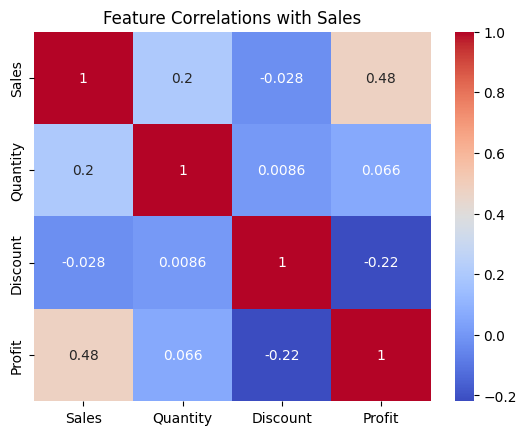

In [4]:
# Task 1 - Step 5
import seaborn as sns
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations with Sales')
plt.show()

In [5]:
# Task 2 - Step 1
X = df[['Quantity', 'Discount', 'Profit']]
y = df['Sales']

In [6]:
# Task 2 - Step 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Task 2 - Step 3
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
# Task 2 - Step 4
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")

MSE: 680377.46, RMSE: 824.85, MAE: 245.08, R2: -0.1518


In [9]:
# Task 3 - Step 1
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Quantity: 41.5503
Discount: 249.5718
Profit: 1.5617
Intercept: -18.0971


In [10]:
# Task 4 - Step 1
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [11]:
# Task 4 - Step 2
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

In [12]:
# Task 4 - Step 3
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression'],
    'MSE': [mse, mse_poly],
    'RMSE': [rmse, rmse_poly],
    'MAE': [mae, mae_poly],
    'R2': [r2, r2_poly]
})
comparison

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,680377.456372,824.849960,245.075570,-0.151817
1,Polynomial Regression,473873.848924,688.384957,190.560721,0.197775


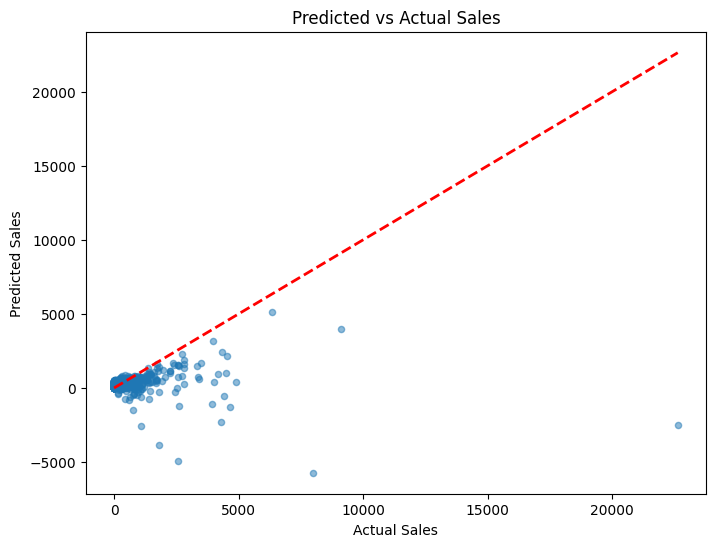

In [13]:
# Task 5 - Step 1
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales')
plt.show()

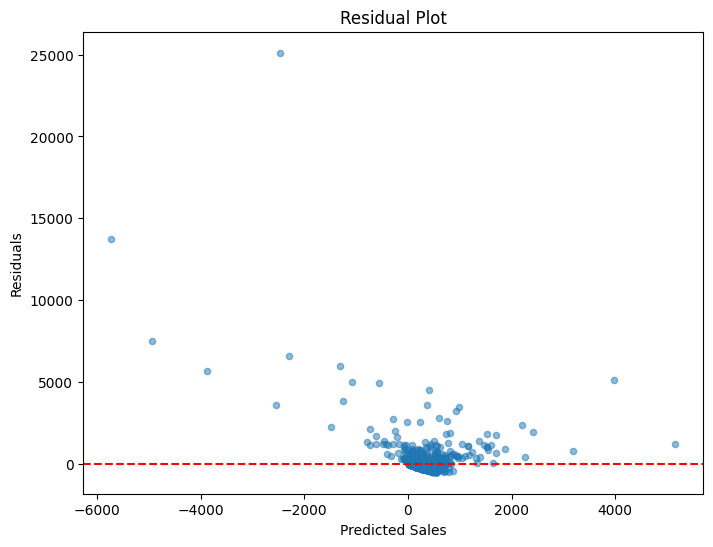

In [14]:
# Task 5 - Step 2
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# **Mod_4 Assignment 2**

In [15]:
# Task 1 - Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, roc_auc_score,
                              classification_report, ConfusionMatrixDisplay)

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_5659/2899067968.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [16]:
# Task 1 - Step 2
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [17]:
# Task 1 - Step 3
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

In [18]:
# Task 1 - Step 4
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# Task 1 - Step 5
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [20]:
# Task 2 - Step 1
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

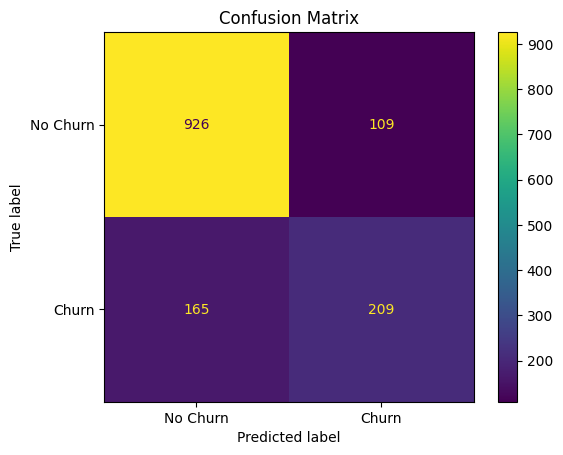

In [21]:
# Task 3 - Step 1
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.show()

In [22]:
# Task 3 - Step 2
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



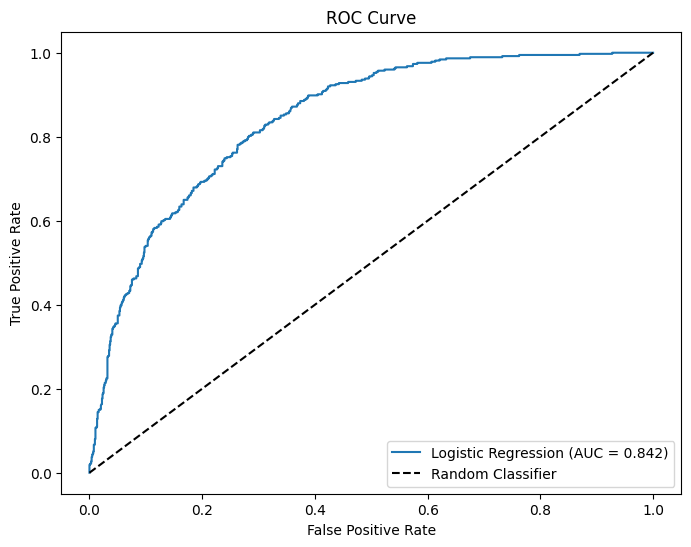

In [23]:
# Task 3 - Step 3
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [24]:
# Task 4 - Step 1
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

In [25]:
# Task 4 - Step 2
coef_df.head(5)

,Feature,Coefficient
10,InternetService_Fiber optic,1.190576
3,TotalCharges,0.511378
23,StreamingMovies_Yes,0.380384
21,StreamingTV_Yes,0.378872
28,PaymentMethod_Electronic check,0.377641


In [26]:
# Task 4 - Step 3
coef_df.tail(5)

,Feature,Coefficient
2,MonthlyCharges,-0.477810
7,PhoneService_Yes,-0.491306
24,Contract_One year,-0.690863
1,tenure,-1.237578
25,Contract_Two year,-1.337453


In [27]:
# Task 5 - Step 1
for threshold in [0.3, 0.5, 0.7]:
    y_pred_t = (y_proba >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision_score(y_test, y_pred_t):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_t):.4f}")
    print(f"F1: {f1_score(y_test, y_pred_t):.4f}")


Threshold: 0.3
Precision: 0.5193
Recall: 0.7540
F1: 0.6150

Threshold: 0.5
Precision: 0.6572
Recall: 0.5588
F1: 0.6040

Threshold: 0.7
Precision: 0.7391
Recall: 0.1818
F1: 0.2918


In [28]:
# Task 5 - Step 2
results = []
for threshold in [0.3, 0.5, 0.7]:
    y_pred_t = (y_proba >= threshold).astype(int)
    results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t)
    })
threshold_table = pd.DataFrame(results)
threshold_table

,Threshold,Precision,Recall,F1
0,0.3,0.519337,0.754011,0.615049
1,0.5,0.657233,0.558824,0.604046
2,0.7,0.739130,0.181818,0.291845
